In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence

In [6]:
peng = pd.read_csv('C:\\Users\\witze\\Downloads\\DS6021_F26\\data\\penguins.csv').dropna(
    subset=["flipper_length_mm", "body_mass_g", "bill_length_mm", "bill_depth_mm"]
).reset_index(drop=True)

peng.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
5,Adelie,Torgersen,38.9,17.8,181.0,3625.0,female,2007
6,Adelie,Torgersen,39.2,19.6,195.0,4675.0,male,2007
7,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,2007
8,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,2007
9,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN,2007


In [13]:
bike = pd.read_csv("C:\\Users\\witze\\Downloads\\DS6021_F26\\data\\bike-sharing-daily.csv", parse_dates=["dteday"])
bike.head(10)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,1518,1606
6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,1362,1510
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,891,959
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,768,822
9,10,2011-01-10,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,1280,1321


In [11]:
#1.1
m = smf.ols("body_mass_g ~ flipper_length_mm + bill_depth_mm + bill_length_mm + C(species)", data=peng).fit()

names = m.model.exog_names
exog = m.model.exog

pd.DataFrame({
    'Feature': names,
    'VIF': [variance_inflation_factor(exog, i) for i in range(exog.shape[1])]
})

,Feature,VIF
0,Intercept,839.362361
1,C(species)[T.Chinstrap],3.683718
2,C(species)[T.Gentoo],15.643684
3,flipper_length_mm,6.516234
4,bill_depth_mm,4.799098
5,bill_length_mm,5.226426


### 1.1

Last week, I came to the conclusion that the additional predictors didn't improve the model's fit in any way. With the VIF values, I'm making the same conclusion.

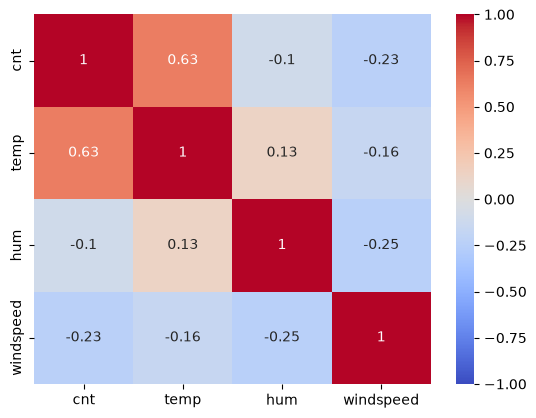

In [27]:
#1.2a
BikeCorr = bike[['cnt', 'temp', 'hum', 'windspeed']].corr()

sns.heatmap(BikeCorr, annot = True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [24]:
#1.2b
def vif_table(df, cols):
    X = sm.add_constant(df[cols])
    return pd.DataFrame({
        "variable": cols,
        "VIF": [variance_inflation_factor(X.values, X.columns.get_loc(c)) for c in cols],
    }).round(2)

model = smf.ols("cnt ~ temp + hum + windspeed", data=bike).fit()
print(vif_table(bike, ["temp", "hum", "windspeed"]))

    variable   VIF
0       temp  1.03
1        hum  1.07
2  windspeed  1.08


### 1.2b
From the vif table and heatmap above, I'm not seeing much correlation amongst each predictor.

In [28]:
#1.2c

m1 = smf.ols("cnt ~ temp", data=bike).fit()
m2 = smf.ols("cnt ~ temp + hum", data=bike).fit()
m3 = smf.ols("cnt ~ temp + hum + windspeed", data=bike).fit()

sm.stats.anova_lm(m1, m2, m3)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,729.0,1.660847e+09,0.0,NaN,NaN,NaN
1,728.0,1.570304e+09,1.0,9.054330e+07,44.569779,4.869005e-11
2,727.0,1.476897e+09,1.0,9.340630e+07,45.979085,2.475445e-11


### 1.2d
From the above F-test, I'm concluding that the model with all three variables is the best one to choose. The p-values and F-statistics both indicate that the variables hum and windspeed contribute significantly to the model fit. 

In [30]:
#2.1
pengsex = pd.read_csv('C:\\Users\\witze\\Downloads\\DS6021_F26\\data\\penguins.csv').dropna(
    subset=["flipper_length_mm", "body_mass_g", "bill_length_mm", "bill_depth_mm", "sex"]
).reset_index(drop=True)

sex = smf.ols("body_mass_g ~ flipper_length_mm + bill_length_mm + bill_depth_mm", data=pengsex).fit()
print(sex.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     354.9
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          9.26e-103
Time:                        20:40:59   Log-Likelihood:                -2459.8
No. Observations:                 333   AIC:                             4928.
Df Residuals:                     329   BIC:                             4943.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -6445.4760    566.13

### 2.1
I'm noticing that the R^2 and R^2adj had the slightest improvement in the pengsex model, despite the drop in the sample size. I also noticed that the bill length and bill depth coefficients shifted down. While these changes are noticeable, they are very insignificant.

In [ ]:
#2.2
additive = smf.ols("body_mass_g ~ flipper_length_mm + C(sex)", data=pengsex).fit()
interaction = smf.ols("body_mass_g ~ flipper_length_mm * C(sex)", data=pengsex).fit()

print(additive.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     684.8
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          3.53e-118
Time:                        20:54:37   Log-Likelihood:                -2427.2
No. Observations:                 333   AIC:                             4860.
Df Residuals:                     330   BIC:                             4872.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5410.3002    285.79

In [33]:
print(interaction.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     455.2
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          1.04e-116
Time:                        20:55:01   Log-Likelihood:                -2427.2
No. Observations:                 333   AIC:                             4862.
Df Residuals:                     329   BIC:                             4878.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

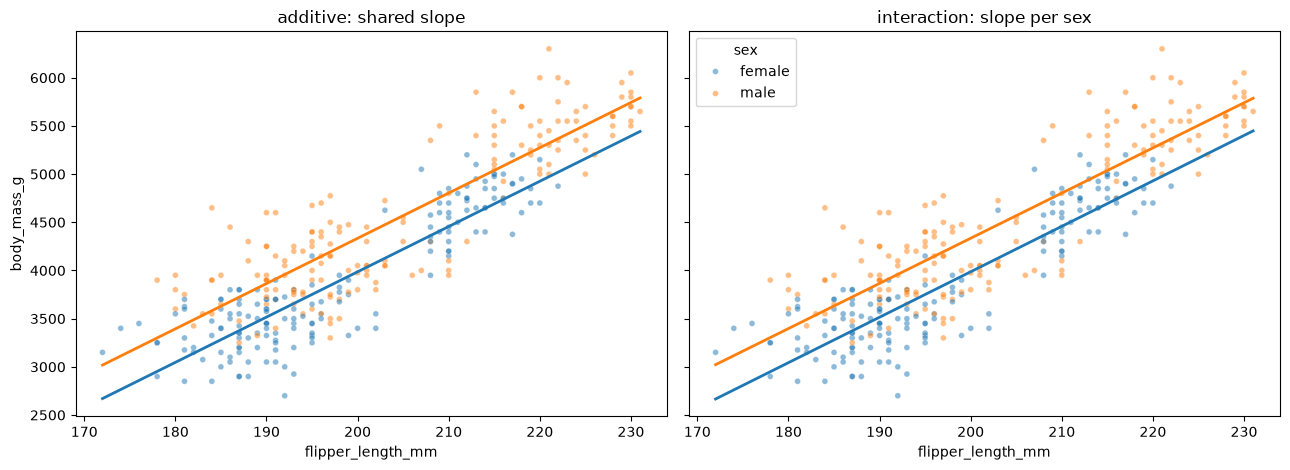

In [35]:
#2.2 Plot
sexes = sorted(pengsex.sex.unique())
palette = dict(zip(sexes, sns.color_palette(n_colors=len(sexes))))

# 3. Create subplots and prediction grid
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
grid = np.linspace(pengsex.flipper_length_mm.min(), pengsex.flipper_length_mm.max(), 50)

# 4. Loop through models and axes
for ax, model, title in [(axes[0], additive, "additive: shared slope"),
                         (axes[1], interaction, "interaction: slope per sex")]:
    sns.scatterplot(data=pengsex, x="flipper_length_mm", y="body_mass_g",
                    hue="sex", hue_order=sexes, palette=palette,
                    alpha=0.5, s=18, ax=ax, legend=(ax is axes[1]))
    for s in sexes:
        pred = model.predict(pd.DataFrame({"flipper_length_mm": grid, "sex": s}))
        ax.plot(grid, pred, lw=2, color=palette[s])
    ax.set_title(title)

plt.tight_layout()
plt.show()

### 2.2

- (a) The additive model is the best. It's nearly identical to the interaction model, but the interaction is shown to have little to no significant effect. The additive model has a better fit than the full model through R^2 and R^2adj, despite having less predictors.

- (b) The impact of sex on body mass is large. Sex has the largest coefficient in both the additive and interaction models. Male and female penguins differ in that the male penguins are automatically predicted to have an extra several hundreds of grams of body mass because of their sex alone.

- (c) These plots help me answer the question by showing how similar the additive and interaction models are. Both plots also showed me the parallel between male and female body mass and how much the sex does affect prediction.

In [36]:
#2.3
addition = smf.ols("body_mass_g ~ C(species) + C(sex)", data=pengsex).fit()
interactive = smf.ols("body_mass_g ~ C(species) * C(sex)", data=pengsex).fit()

print(addition.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     606.1
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          1.27e-133
Time:                        21:33:30   Log-Likelihood:                -2387.8
No. Observations:                 333   AIC:                             4784.
Df Residuals:                     329   BIC:                             4799.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                3

In [37]:
print(interactive.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                     384.3
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          1.54e-134
Time:                        21:33:49   Log-Likelihood:                -2379.1
No. Observations:                 333   AIC:                             4770.
Df Residuals:                     327   BIC:                             4793.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

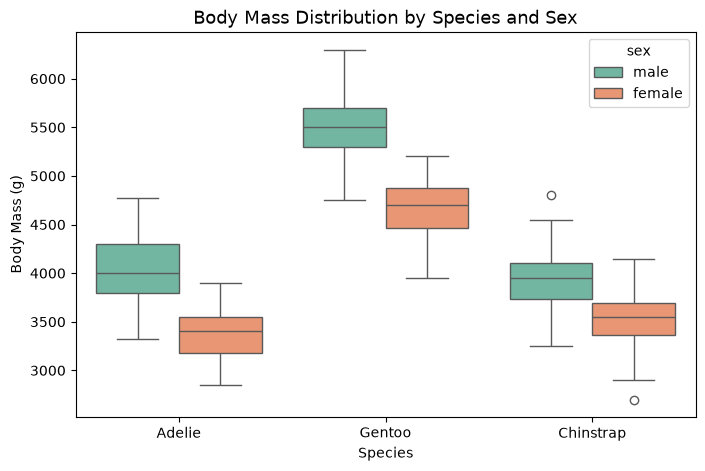

In [ ]:
#2.3 Plot. AI: I fed my models to AI and had it create a boxplot for me.
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=pengsex, 
    x="species", 
    y="body_mass_g", 
    hue="sex", 
    palette="Set2"
)

plt.title("Body Mass Distribution by Species and Sex", fontsize=13)
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.show()

### 2.3

- (a) The interaction model is the better one here as indicated by the R^2, R^2adj, and the coefficients.

- (b) In the interaction model, a penguin being from the chinstrap species, gentoo species, and male will predict more body mass than Adelie. However, if a penguin is both a chinstrap and male, then that takes away from it's body mass prediction. Finally, a penguin of gentoo species and male sex predicts even more body mass.

- (c) This boxplots above helped me answer this question by showing the differences between species and sex. The differences between the Gentoo species and Chinstrap/Adelie is larger than the difference between male and female. 

In [39]:
#2.4a
casual_add = smf.ols("casual ~ temp + C(workingday) + hum + windspeed", data=bike).fit()
casual_int = smf.ols("casual ~ temp * C(workingday) + hum + windspeed", data=bike).fit()

print(casual_add.summary())

                            OLS Regression Results                            
Dep. Variable:                 casual   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.627
Method:                 Least Squares   F-statistic:                     307.9
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          9.84e-155
Time:                        22:12:02   Log-Likelihood:                -5448.9
No. Observations:                 731   AIC:                         1.091e+04
Df Residuals:                     726   BIC:                         1.093e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           1063.5527    101

In [40]:
print(casual_int.summary())

                            OLS Regression Results                            
Dep. Variable:                 casual   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     307.4
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          2.25e-176
Time:                        22:12:14   Log-Likelihood:                -5395.6
No. Observations:                 731   AIC:                         1.080e+04
Df Residuals:                     725   BIC:                         1.083e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

### 2.4a

The interaction model is better. The R^2 and R^2adj are higher in this model, and the large interaction coeffecient indicates a heavy impact from that interaction.

In [41]:
#2.4b

reg_add = smf.ols("registered ~ temp + C(workingday) + hum + windspeed", data=bike).fit()
reg_int = smf.ols("registered ~ temp * C(workingday) + hum + windspeed", data=bike).fit()
print(reg_add.summary())

                            OLS Regression Results                            
Dep. Variable:             registered   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.422
Method:                 Least Squares   F-statistic:                     134.5
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           5.97e-86
Time:                        22:13:53   Log-Likelihood:                -6208.8
No. Observations:                 731   AIC:                         1.243e+04
Df Residuals:                     726   BIC:                         1.245e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           2945.8161    286

In [42]:
print(reg_int.summary())

                            OLS Regression Results                            
Dep. Variable:             registered   R-squared:                       0.428
Model:                            OLS   Adj. R-squared:                  0.424
Method:                 Least Squares   F-statistic:                     108.4
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           1.89e-85
Time:                        22:14:22   Log-Likelihood:                -6207.4
No. Observations:                 731   AIC:                         1.243e+04
Df Residuals:                     725   BIC:                         1.245e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                3

### 2.4

- (b) The additive model is better. Both R^2 and R^2adjs are very similar to each other and the p-value shows that the interaction isn't a significant predictor. 

- (c) This data is telling me that casual riders make their decisions a lot more based on the predictors, whereas registered drivers may be more dutiful with their biking. 

- (d) This is because of the collinnearity between casual and registered riders. cnt doesn't account for how different the two are. Having separate models is necessary.

In [46]:
#3.1a
model = smf.ols("body_mass_g ~ flipper_length_mm + bill_depth_mm + bill_length_mm + C(species)", data=peng).fit()
infl = OLSInfluence(model)

diag = pd.DataFrame({
    "body_mass_g":      peng.body_mass_g,
    "sex":       peng.sex,
    "fitted":    model.fittedvalues,
    "residuals": model.resid,
    "student_resid": infl.resid_studentized_external,
    "leverage":  infl.hat_matrix_diag,
    "cooks_d":   infl.cooks_distance[0],
})

diag.head(10)

,body_mass_g,sex,fitted,residuals,student_resid,leverage,cooks_d
0,3750.0,male,3581.854904,168.145096,0.536126,0.016301,0.000796
1,3800.0,female,3517.220525,282.779475,0.900060,0.011318,0.001547
2,3250.0,female,3816.761552,-566.761552,-1.810128,0.010847,0.005948
3,3450.0,female,3809.420112,-359.420112,-1.146950,0.014918,0.003317
4,3650.0,male,4038.941778,-388.941778,-1.247266,0.023848,0.006324
5,3625.0,female,3447.265681,177.734319,0.566020,0.013838,0.000751
6,4675.0,male,3995.671709,679.328291,2.175232,0.011689,0.009225
7,3475.0,NaN,3533.208194,-58.208194,-0.185881,0.020063,0.000118
8,4250.0,NaN,4094.775131,155.224869,0.495343,0.018064,0.000754
9,3300.0,NaN,3404.625716,-104.625716,-0.332546,0.010604,0.000198


In [ ]:
#3.1b
n, p = int(model.nobs), model.df_model
lev_cut, cook_cut = 2 * (p + 1) / n, 4 / n
print(f"n = {n}, p = {p:.0f}   leverage cutoff = {lev_cut:.4f}   Cook's D cutoff = {cook_cut:.4f}")

print(f"\noutliers   (|studentized resid| > 3): {(diag.student_resid.abs() > 3).sum()}")
print(f"high leverage (h > 2(p+1)/n):        {(diag.leverage > lev_cut).sum()}")
print(f"influential   (Cook's D > 4/n):      {(diag.cooks_d > cook_cut).sum()}")

n = 342, p = 5   leverage cutoff = 0.0351   Cook's D cutoff = 0.0117

outliers   (|studentized resid| > 3): 1
high leverage (h > 2(p+1)/n):        14
influential   (Cook's D > 4/n):      9


### 3.1

- (b) Some of these data points exceed the cutoff. I'm noticing that the 9 penguins missing their sex data are not influential in any way. 

- (c) The information on studentized residuals, leverage, and Cook's distance supports my conclusion from earlier that the penguins without sex data are very insignificant. They have little to no influence on the full analysis, showing just how important the gender predictor is.

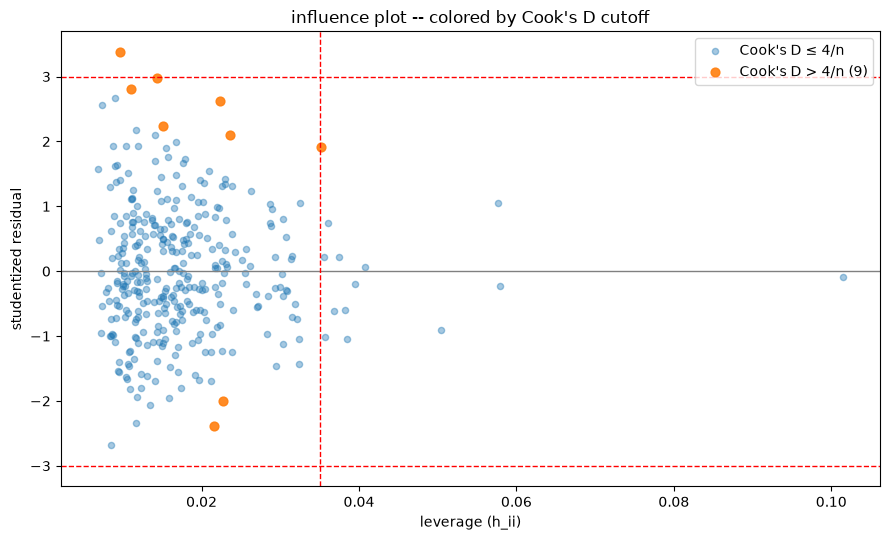

In [49]:
#3.1d
infl = diag.cooks_d > cook_cut

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(diag.leverage[~infl], diag.student_resid[~infl], s=20, alpha=0.4,
           color="tab:blue", label=f"Cook's D ≤ 4/n")
ax.scatter(diag.leverage[infl], diag.student_resid[infl], s=40, alpha=0.9,
           color="tab:orange", label=f"Cook's D > 4/n ({infl.sum()})")
ax.axhline(0, color="gray", lw=1)
for y in (-3, 3):
    ax.axhline(y, color="red", ls="--", lw=1)
ax.axvline(lev_cut, color="red", ls="--", lw=1)
ax.set(xlabel="leverage (h_ii)", ylabel="studentized residual",
       title="influence plot -- colored by Cook's D cutoff")
ax.legend()

plt.tight_layout()

### 3.1d

From the plot above, I'm noticing that the most residual data points also fail Cook's cutoff. They are either seen at the top right or the bottom right.

### 3.2

When you remove these influential data points, you'll see an obvious drop in the influence of weather, humidity, and windspeed. I would actually not remove these data points, unless I was only conducting my analysis in standard weather days. This is because our goal is to generalize bike rider data and those data points are part of the decisions made by bikers to not ride. If I did decide to cut those points out, I would report my analysis as one that only takes normal weathered days to stakeholders. 

### 5

These readings go into depth on data preprocessing and the preparation of predictors for statistical modeling. When working with skewed, largely scaled, or any unprepared datasets, there is a preprocessing method configured to shift that data into a format cleaner for analysis. These articles relate to the topics of outliers, leverage, and influence because preprocessing is the solution to these problematic topics. Outliers, leverage, and influence all have heavy impacts on how raw data can be interpreted, so data scientists need to utilize these methods to combat these impacts without the need to cut values out of their data. My question about feature transformations is: Is there a feature transformation for every shape of data? Like a dataset with multiple peaks?